# Part 0: Setup and Orientation

This notebook prepares your environment for the full Machine Gnostics + Anscombe tutorial series.

By the end of this notebook, you will:
- install and import required packages
- load all four Anscombe datasets
- verify data shape and baseline statistics
- understand what each next notebook (Part 1 to Part 4) will cover

## Step 1: Install Dependencies
Run this cell once per environment. If everything is already installed, it is safe to skip.

In [1]:
%pip install -q machinegnostics numpy pandas matplotlib seaborn scipy scikit-learn


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Step 2: Import Libraries
We import both classical statistical tools and Machine Gnostics APIs so you can compare them side by side in later notebooks.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from machinegnostics.data import make_anscombe_check_data
from machinegnostics.metrics import mean as mg_mean, median as mg_median, correlation as mg_correlation
from machinegnostics.magcal import EGDF, ELDF, QGDF, QLDF, IntervalAnalysis
from machinegnostics.models import LinearRegressor

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

plt.style.use("seaborn-v0_8")
sns.set_context("notebook")

print("Libraries imported successfully.")

Libraries imported successfully.


## Step 3: Load Anscombe Quartet
Each dataset has the same classical summary statistics but very different structure when plotted.

In [3]:
dataset_labels = {
    1: "Anscombe I (Linear)",
    2: "Anscombe II (Non-linear)",
    3: "Anscombe III (Outlier in y)",
    4: "Anscombe IV (Leverage point in x)",
}

datasets = {}
for ds_id in [1, 2, 3, 4]:
    x, y = make_anscombe_check_data(ds_id)
    datasets[ds_id] = {"x": np.asarray(x, dtype=float), "y": np.asarray(y, dtype=float)}

print("Loaded datasets:")
for ds_id, meta in datasets.items():
    print(f"- {dataset_labels[ds_id]} | n={len(meta['x'])}")

Loaded datasets:
- Anscombe I (Linear) | n=11
- Anscombe II (Non-linear) | n=11
- Anscombe III (Outlier in y) | n=11
- Anscombe IV (Leverage point in x) | n=11


## Step 4: Quick Baseline Check
These values should look very similar across all four datasets, which is exactly why Anscombe is a classic teaching example.

In [4]:
rows = []
for ds_id in [1, 2, 3, 4]:
    x = datasets[ds_id]["x"]
    y = datasets[ds_id]["y"]
    rows.append({
        "Dataset": ds_id,
        "mean_x": np.mean(x),
        "mean_y": np.mean(y),
        "corr_xy": np.corrcoef(x, y)[0, 1],
        "median_x": np.median(x),
        "median_y": np.median(y),
    })

baseline_df = pd.DataFrame(rows)
baseline_df.round(4)

,Dataset,mean_x,mean_y,corr_xy,median_x,median_y
0,1,9.0,7.5009,0.8164,9.0,7.58
1,2,9.0,7.5009,0.8162,9.0,8.14
2,3,9.0,7.5000,0.8163,9.0,7.11
3,4,9.0,7.5009,0.8165,8.0,7.04


## Step 5: Visual Sanity Check
Even with near-identical summary statistics, the scatter patterns are clearly different.

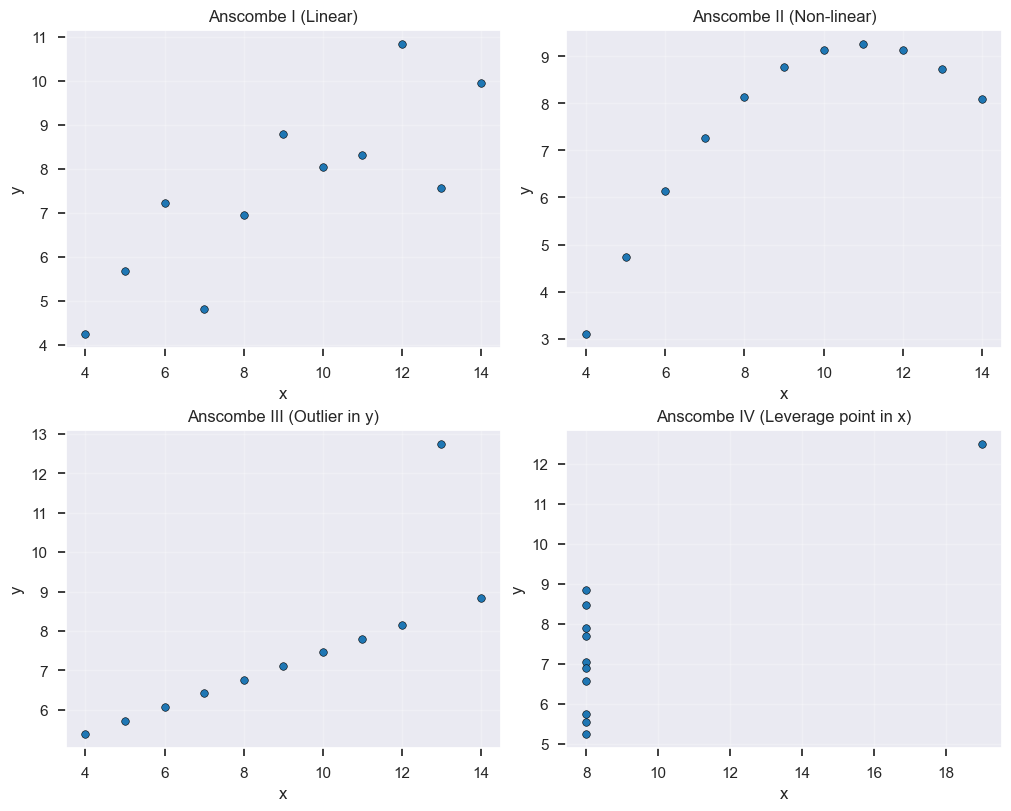

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8), constrained_layout=True)
axes = axes.ravel()

for i, ds_id in enumerate([1, 2, 3, 4]):
    x = datasets[ds_id]["x"]
    y = datasets[ds_id]["y"]
    ax = axes[i]
    ax.scatter(x, y, s=30, c="tab:blue", edgecolor="black", linewidth=0.4)
    ax.set_title(dataset_labels[ds_id])
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.grid(alpha=0.25)

plt.show()

## What Comes Next
- Part 1: Gnostic metrics vs NumPy/scikit-learn metrics
- Part 2: GDF tutorials and the ELDF/CDF/PDF presentation plot
- Part 3: Marginal interval analysis
- Part 4: Linear regression comparison poster